__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

# Introduction
The goal of this file is to demonstrate the limitations of the integral parameter estimation used to calculate insulin sensitivity $S_I$

In [2]:
try:
    SI_ests_02 = np.load("../scripts/saved_variables/module2/SI_ests_02.npy")
    SI_ests_vary_02 = np.load("../scripts/saved_variables/module2/SI_ests_02.npy")
    SI_est_error_02 = np.load("../scripts/saved_variables/module2/SI_est_error_02.npy")
    SI_est_error_vary_02 = np.load("../scripts/saved_variables/module2/SI_est_error_02.npy")
    meas_noise_std_02 = np.load("../scripts/saved_variables/module2/meas_noise_std_02.npy")
    print("Loaded variables")
except Exception:
    print("Run 02_Integral_Estimation.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "02"
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]

# Plot Results
+ The distribution of $\,SI$ estimates will be plotted over time
+ The MARD (90% CI) error will be plotted along for each measurement noise std $\sigma$

In [4]:
mean_err = np.mean(SI_est_error_02, axis=1)
mean_SI = np.mean(SI_ests_02, axis=1)
mean_err_vary = np.mean(SI_est_error_vary_02, axis=1)
mean_SI_vary = np.mean(SI_ests_vary_02, axis=1)

time = 60 * np.arange(SI_ests_02.shape[2])

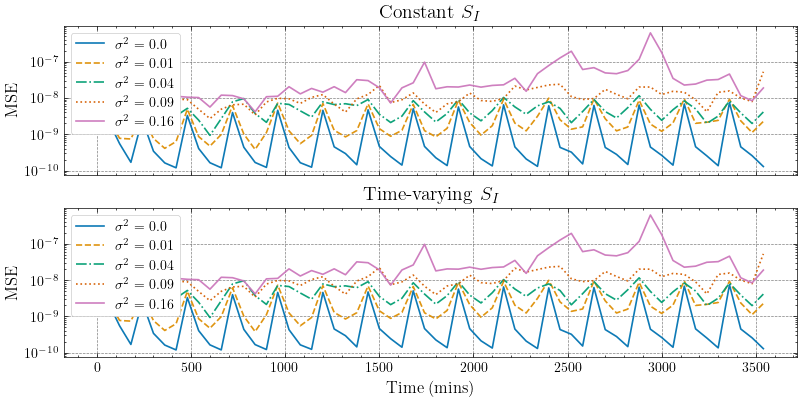

In [5]:
num_plots = mean_err.shape[0]
palette = sns.color_palette("colorblind", num_plots)

fig, ax = plt.subplots(2,1,figsize=(8,4), sharex=True)
for i in range(num_plots):
    ax[0].plot(
        time,
        mean_err[i, :],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"$\\sigma^2$ = {np.round(meas_noise_std_02[i]**2,2)}",
    )
    # ax[0].fill_between(time, ci_low[i, :], ci_high[i, :], color=palette[i], alpha=0.18, label=f"{CI}% CI")

ax[0].legend()
ax[0].set_ylabel("MSE")
ax[0].set_yscale('log')
ax[0].set_title(r'Constant $S_I$')

for i in range(num_plots):
    ax[1].plot(
        time,
        mean_err_vary[i, :],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"$\\sigma^2$ = {np.round(meas_noise_std_02[i]**2,2)}",
    )
    # ax[1].fill_between(time, ci_low[i, :], ci_high[i, :], color=palette[i], alpha=0.18, label=f"{CI}% CI")

ax[1].legend()
ax[1].set_xlabel("Time (mins)")
ax[1].set_ylabel("MSE")
ax[1].set_yscale('log')
ax[1].set_title(r'Time-varying $S_I$')

fig.savefig("figures/5_11.pdf", format="pdf")